In [1]:

!pip install git+https://github.com/facebookresearch/segment-anything.git

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-5h_zeubb
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-5h_zeubb
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done


In [3]:
import glob
import cv2
import numpy as np
import torch
import os
import joblib
from tqdm import tqdm
from segment_anything import sam_model_registry, SamPredictor
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

FRAME_DIR_GLOB = "/kaggle/input/car-yt-obj-dataset/car/data/000*/shots/0*/frame*.jpg"
SAM_CHECKPOINT_PATH = "/kaggle/input/sam-vit-b-01ec64-pth/sam_vit_b_01ec64.pth"

OUTPUT_DIR = "sam_coloc_output"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


FRAME_SAMPLE_RATE = 30 
PCA_COMPONENTS = 64    
N_CLUSTERS = 5         
KMEANS_SUBSET_RATIO = 0.1

PCA_MODEL_PATH = os.path.join(OUTPUT_DIR, 'sam_pca_model.joblib')
KMEANS_MODEL_PATH = os.path.join(OUTPUT_DIR, 'sam_kmeans_model.joblib')
VIS_FILE_PATH = os.path.join(OUTPUT_DIR, 'sam_cluster_visualization.jpg')




def get_frames(frame_paths):
    frames = []
    for path in tqdm(frame_paths, total=len(frame_paths), desc="Loading frames"):
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        frames.append(img)
    return frames

@torch.no_grad()
def extract_sam_features(predictor, frame_rgb):
    """
    Uses SamPredictor to get dense image embeddings.
    SAM's ViT-B encoder produces a 64x64 feature map (4096 patches)
    with 256 channels.
    """
    predictor.set_image(frame_rgb)
    features = predictor.get_image_embedding().cpu().numpy()
    
    c, h, w = features.shape[1], features.shape[2], features.shape[3]
    return features.reshape(c, h * w).transpose(1, 0)

def visualize_all_clusters_one_image(frame, patch_labels, color_map):
    """
    Creates a 2-panel visualization with a blended cluster map.
    """
    patch_grid_size = (64, 64) # SAM's feature map size
    target_size = (frame.shape[0], frame.shape[1])
    frame_float = frame.astype(np.float32) / 255.0
    
    mask = patch_labels.reshape(patch_grid_size)
    mask_rgb_lowres = np.zeros((*patch_grid_size, 3), dtype=np.float32)

    for k in range(len(color_map)):
        mask_rgb_lowres[mask == k] = color_map[k]
        
    mask_rgb_full = cv2.resize(mask_rgb_lowres, (target_size[1], target_size[0]), interpolation=cv2.INTER_NEAREST)
    
    blended_img = cv2.addWeighted(frame_float, 0.6, mask_rgb_full, 0.4, 0)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    axes[0].imshow(frame)
    axes[0].set_title("Original")
    axes[0].axis('off')
    
    axes[1].imshow(blended_img)
    axes[1].set_title("Cluster Map")
    axes[1].axis('off')
    
    plt.tight_layout()
    return fig


# --- 4. Run Script ---
if __name__ == "__main__":
    main()

Using device: cuda
Loading SAM model (ViT-Base)...
Loading frames...


Loading frames: 100%|██████████| 471/471 [00:04<00:00, 96.82it/s] 



--- Part 1: Extracting SAM Features ---


Extracting SAM features: 100%|██████████| 471/471 [01:56<00:00,  4.03it/s]


Total features extracted: (1929216, 256)

--- Part 2: Running PCA and K-Means ---
Running PCA to reduce to 64 dims...
Training K-Means on a 10.0% subset...
Saving PCA and K-Means models...

--- Part 3: Generating Cluster Visualization ---
Generating 3D color map from K-Means centroids...
Visualizing a random sample frame...

Visualization saved to: sam_coloc_output/sam_cluster_visualization.jpg
!!! ACTION REQUIRED !!!
Open sam_coloc_output/sam_cluster_visualization.jpg and identify the cluster ID for your common object.


In [6]:
 os.makedirs(OUTPUT_DIR, exist_ok=True)
    
if not os.path.exists(SAM_CHECKPOINT_PATH):
    print(f"Error: SAM Checkpoint not found at {SAM_CHECKPOINT_PATH}")
    print("Please download 'sam_vit_b_01ec64.pth' and update the path.")

print(f"Using device: {DEVICE}")
print("Loading SAM model (ViT-Base)...")
sam = sam_model_registry["vit_b"](checkpoint=SAM_CHECKPOINT_PATH)
sam.to(device=DEVICE)
predictor = SamPredictor(sam)

print("Loading frames...")
frame_paths = glob.glob(FRAME_DIR_GLOB)
frame_paths_sampled = frame_paths[::FRAME_SAMPLE_RATE]

if not frame_paths_sampled:
     print(f"No frames found. Check FRAME_DIR_GLOB: {FRAME_DIR_GLOB}")
     
frames = get_frames(frame_paths_sampled)


Using device: cuda
Loading SAM model (ViT-Base)...
Loading frames...


Loading frames: 100%|██████████| 471/471 [00:02<00:00, 187.08it/s]


In [7]:
print("\n--- Part 1: Extracting SAM Features ---")
all_features_list = []
for frame in tqdm(frames, desc="Extracting SAM features"):
    features = extract_sam_features(predictor, frame)
    all_features_list.append(features)

all_features = np.vstack(all_features_list)
print(f"Total features extracted: {all_features.shape}")


--- Part 1: Extracting SAM Features ---


Extracting SAM features: 100%|██████████| 471/471 [01:55<00:00,  4.10it/s]


Total features extracted: (1929216, 256)


In [9]:
 print("\n--- Part 2: Running PCA and K-Means ---")
print(f"Running PCA to reduce to {PCA_COMPONENTS} dims...")
pca = PCA(n_components=PCA_COMPONENTS)
features_pca = pca.fit_transform(all_features)

print(f"Training K-Means on a {KMEANS_SUBSET_RATIO*100}% subset...")
n_samples = features_pca.shape[0]
subset_indices = np.random.choice(n_samples, int(n_samples * KMEANS_SUBSET_RATIO), replace=False)
features_subset = features_pca[subset_indices]

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
kmeans.fit(features_subset)

print("Saving PCA and K-Means models...")
joblib.dump(pca, PCA_MODEL_PATH)
joblib.dump(kmeans, KMEANS_MODEL_PATH)


--- Part 2: Running PCA and K-Means ---
Running PCA to reduce to 64 dims...
Training K-Means on a 10.0% subset...
Saving PCA and K-Means models...


['sam_coloc_output/sam_kmeans_model.joblib']


--- Part 3: Generating Cluster Visualization ---
Generating 3D color map from K-Means centroids...
Visualizing a random sample frame...


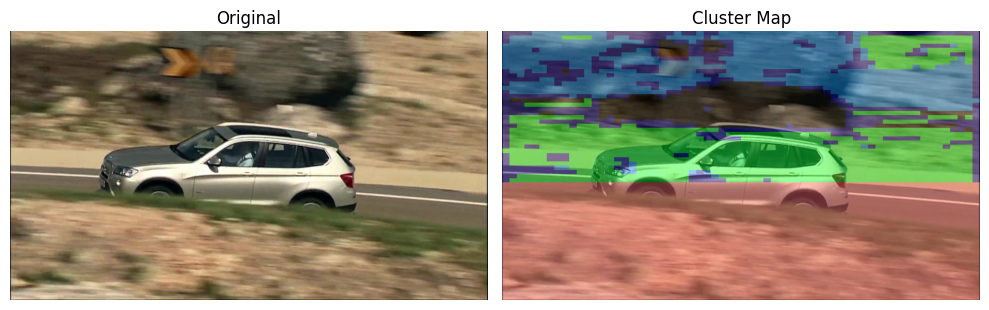


Visualization saved to: sam_coloc_output/sam_cluster_visualization.jpg
!!! ACTION REQUIRED !!!
Open sam_coloc_output/sam_cluster_visualization.jpg and identify the cluster ID for your common object.


In [12]:
print("\n--- Part 3: Generating Cluster Visualization ---")
    
print("Generating 3D color map from K-Means centroids...")
centroids_pca = kmeans.cluster_centers_
pca_color = PCA(n_components=3)
centroids_3d = pca_color.fit_transform(centroids_pca)
scaler = MinMaxScaler()
color_map = scaler.fit_transform(centroids_3d)

print("Visualizing a random sample frame...")
sample_frame = frames[np.random.randint(len(frames))]

features_sample_256d = extract_sam_features(predictor, sample_frame)
features_sample_64d = pca.transform(features_sample_256d)
patch_labels = kmeans.predict(features_sample_64d)

fig = visualize_all_clusters_one_image(sample_frame, patch_labels, color_map)

plt.savefig(VIS_FILE_PATH)
plt.show()
plt.close(fig)

print(f"\nVisualization saved to: {VIS_FILE_PATH}")
print("!!! ACTION REQUIRED !!!")
print(f"Open {VIS_FILE_PATH} and identify the cluster ID for your common object.")